<h1 style='color:purple' align='center'>RiskProof AI: Full Model Benchmark on Fraud Oracle</h1>

This notebook keeps the same tutorial-style workflow as the reference notebooks, but it is adapted to the `fraud_oracle.csv` dataset for the RiskProof AI project.

Project goal:
RiskProof AI solves the problem that Indian MSMEs have no structured, verified, pre-claim evidence system, causing slow, disputed, and reduced insurance settlements.

The dataset is used here for the tabular fraud and risk-scoring part of the project to build baseline models that predict:
- fraud probability
- claim risk score
- high-risk vs low-risk claim

This notebook includes:
- data loading and cleaning
- one hot encoding
- train test split
- linear regression
- multiple linear regression
- logistic regression binary classification
- logistic regression multiclass classification
- decision tree
- svm
- random forest
- kmeans
- naive bayes
- knn
- final comparison
- model saving using pickle and joblib

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

import pickle
import joblib

%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (16, 8)

## 1. Load Dataset

In [19]:
df = pd.read_csv('fraud_oracle.csv')
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (15420, 33)


,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


## 2. Clean Data

In [20]:
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())

print('Missing values before:', df.isnull().sum().sum())
df = df.dropna()
print('Missing values after:', df.isnull().sum().sum())
print('Cleaned shape:', df.shape)

Duplicates before: 0
Duplicates after: 0
Missing values before: 0
Missing values after: 0
Cleaned shape: (15420, 33)


## 3. Prepare Features

Encoded input shape: (15420, 120)
Binary target distribution:
FraudFound_P
0    14497
1      923
Name: count, dtype: int64
Multiclass target classes: ['All Perils', 'Collision', 'Liability']
Multiclass target distribution:
BasePolicy
Collision     5962
Liability     5009
All Perils    4449
Name: count, dtype: int64


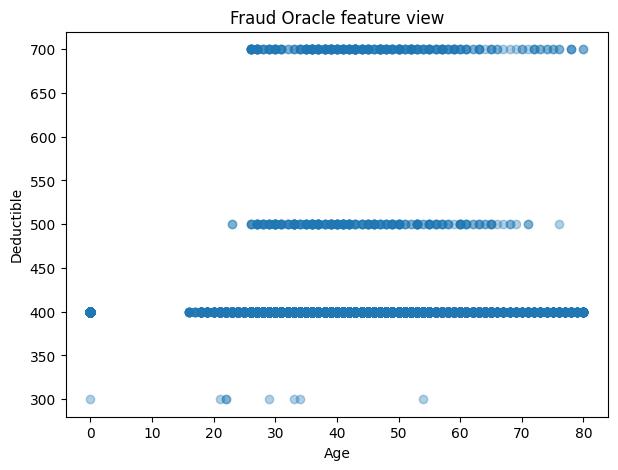

In [21]:
binary_target = df['FraudFound_P']
multiclass_target_source = df['BasePolicy']
feature_source = df.drop(['FraudFound_P', 'BasePolicy', 'PolicyNumber', 'RepNumber'], axis='columns')

inputs = pd.get_dummies(feature_source, drop_first=True)
multiclass_encoder = LabelEncoder()
multiclass_target = multiclass_encoder.fit_transform(multiclass_target_source)

print('Encoded input shape:', inputs.shape)
print('Binary target distribution:')
print(binary_target.value_counts())
print('Multiclass target classes:', list(multiclass_encoder.classes_))
print('Multiclass target distribution:')
print(multiclass_target_source.value_counts())

plt.figure(figsize=(7, 5))
plt.scatter(df['Age'], df['Deductible'], alpha=0.35)
plt.xlabel('Age')
plt.ylabel('Deductible')
plt.title('Fraud Oracle feature view')
plt.show()

## 4. Split Data

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    inputs,
    binary_target,
    test_size=0.2,
    random_state=42,
    stratify=binary_target
)

print('Length of X_train:', len(X_train))
print('Length of X_test:', len(X_test))
print('Length of inputs:', len(inputs))

Length of X_train: 12336
Length of X_test: 3084
Length of inputs: 15420


## 5. Regression Baselines

In [23]:
binary_results = []
trained_models = {}

def score_regression_as_classification(y_true, y_pred):
    clipped = np.clip(y_pred, 0, 1)
    class_pred = (clipped >= 0.5).astype(int)
    return accuracy_score(y_true, class_pred), class_pred

# Simple linear regression baseline using one feature
simple_reg_X = df[['Age']].copy()
X_train_sr, X_test_sr, y_train_sr, y_test_sr = train_test_split(
    simple_reg_X, binary_target, test_size=0.2, random_state=42, stratify=binary_target
)
simple_reg_model = LinearRegression()
simple_reg_model.fit(X_train_sr, y_train_sr)
simple_reg_pred = simple_reg_model.predict(X_test_sr)
simple_reg_accuracy, simple_reg_class_pred = score_regression_as_classification(y_test_sr, simple_reg_pred)
print('Simple Linear Regression accuracy:', simple_reg_accuracy)
print('MAE:', mean_absolute_error(y_test_sr, simple_reg_pred))
print('RMSE:', root_mean_squared_error(y_test_sr, simple_reg_pred))
print('R2:', r2_score(y_test_sr, simple_reg_pred))
binary_results.append({'model': 'Simple Linear Regression', 'accuracy': simple_reg_accuracy})
trained_models['Simple Linear Regression'] = {'model': simple_reg_model, 'features': ['Age'], 'scaler': None}

Simple Linear Regression accuracy: 0.9400129701686122
MAE: 0.11252153197412733
RMSE: 0.2372729941904684
R2: 0.00159805942203739


In [24]:
# Multiple linear regression baseline using all encoded features
multi_reg_model = LinearRegression()
multi_reg_model.fit(X_train, y_train)
multi_reg_pred = multi_reg_model.predict(X_test)
multi_reg_accuracy, multi_reg_class_pred = score_regression_as_classification(y_test, multi_reg_pred)
print('Multiple Linear Regression accuracy:', multi_reg_accuracy)
print('MAE:', mean_absolute_error(y_test, multi_reg_pred))
print('RMSE:', root_mean_squared_error(y_test, multi_reg_pred))
print('R2:', r2_score(y_test, multi_reg_pred))
binary_results.append({'model': 'Multiple Linear Regression', 'accuracy': multi_reg_accuracy})
trained_models['Multiple Linear Regression'] = {'model': multi_reg_model, 'features': inputs.columns.tolist(), 'scaler': None}

Multiple Linear Regression accuracy: 0.9400129701686122
MAE: 0.11603664921836039
RMSE: 0.22956572998305944
R2: 0.0654061744922354


## 6. Logistic Regression Binary Classification

Base Logistic Regression accuracy: 0.9406614785992218
C=0.1, accuracy=0.9400129701686122
C=1.0, accuracy=0.9406614785992218
C=5.0, accuracy=0.9406614785992218
C=10.0, accuracy=0.9406614785992218
Best C: 1.0
Best Logistic Regression accuracy: 0.9406614785992218
Cross validation mean: 0.938651102464332
Sample predictions: [0 0 0 0 0 0 0 0 0 0]
Confusion matrix:
 [[2898    1]
 [ 182    3]]

Classification report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      2899
           1       0.75      0.02      0.03       185

    accuracy                           0.94      3084
   macro avg       0.85      0.51      0.50      3084
weighted avg       0.93      0.94      0.91      3084



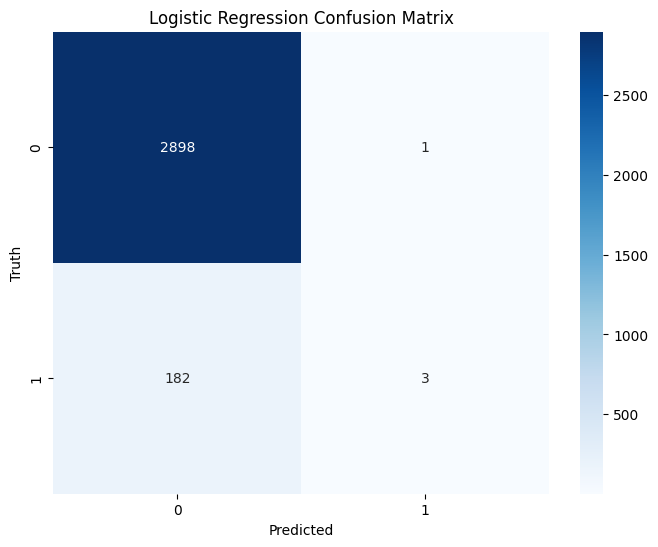

In [25]:
scaler_lr = StandardScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_test_lr = scaler_lr.transform(X_test)

base_lr = LogisticRegression(max_iter=5000, solver='lbfgs')
base_lr.fit(X_train_lr, y_train)
base_lr_accuracy = base_lr.score(X_test_lr, y_test)
print('Base Logistic Regression accuracy:', base_lr_accuracy)

best_lr = None
best_lr_accuracy = -1
best_lr_c = None
for c_value in [0.1, 1.0, 5.0, 10.0]:
    model = LogisticRegression(max_iter=5000, solver='lbfgs', C=c_value)
    model.fit(X_train_lr, y_train)
    score = model.score(X_test_lr, y_test)
    print(f'C={c_value}, accuracy={score}')
    if score > best_lr_accuracy:
        best_lr_accuracy = score
        best_lr = model
        best_lr_c = c_value

print('Best C:', best_lr_c)
print('Best Logistic Regression accuracy:', best_lr_accuracy)
print('Cross validation mean:', cross_val_score(LogisticRegression(max_iter=5000, solver='lbfgs', C=best_lr_c), scaler_lr.fit_transform(inputs), binary_target, cv=5).mean())

y_pred_lr = best_lr.predict(X_test_lr)
print('Sample predictions:', y_pred_lr[:10])
cm_lr = confusion_matrix(y_test, y_pred_lr)
print('Confusion matrix:\n', cm_lr)
print('\nClassification report:\n', classification_report(y_test, y_pred_lr, zero_division=0))
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Logistic Regression Confusion Matrix')
plt.show()
binary_results.append({'model': 'Logistic Regression', 'accuracy': best_lr_accuracy})
trained_models['Logistic Regression'] = {'model': best_lr, 'features': inputs.columns.tolist(), 'scaler': scaler_lr}

## 7. Decision Tree

In [26]:
base_tree = DecisionTreeClassifier(random_state=42)
base_tree.fit(X_train, y_train)
base_tree_accuracy = base_tree.score(X_test, y_test)
print('Base Decision Tree accuracy:', base_tree_accuracy)

best_tree = None
best_tree_accuracy = -1
best_tree_params = None
for criterion in ['gini', 'entropy']:
    for max_depth in [3, 5, 7, 10, None]:
        model = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, random_state=42)
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
        print(f'criterion={criterion}, max_depth={max_depth}, accuracy={score}')
        if score > best_tree_accuracy:
            best_tree_accuracy = score
            best_tree = model
            best_tree_params = {'criterion': criterion, 'max_depth': max_depth}

print('Best parameters:', best_tree_params)
print('Best Decision Tree accuracy:', best_tree_accuracy)
print('Confusion matrix:\n', confusion_matrix(y_test, best_tree.predict(X_test)))
binary_results.append({'model': 'Decision Tree', 'accuracy': best_tree_accuracy})
trained_models['Decision Tree'] = {'model': best_tree, 'features': inputs.columns.tolist(), 'scaler': None}

Base Decision Tree accuracy: 0.8975356679636836
criterion=gini, max_depth=3, accuracy=0.940337224383917
criterion=gini, max_depth=5, accuracy=0.9409857328145266
criterion=gini, max_depth=7, accuracy=0.9406614785992218
criterion=gini, max_depth=10, accuracy=0.9357976653696498
criterion=gini, max_depth=None, accuracy=0.8975356679636836
criterion=entropy, max_depth=3, accuracy=0.940337224383917
criterion=entropy, max_depth=5, accuracy=0.9416342412451362
criterion=entropy, max_depth=7, accuracy=0.9409857328145266
criterion=entropy, max_depth=10, accuracy=0.9361219195849546
criterion=entropy, max_depth=None, accuracy=0.9011024643320363
Best parameters: {'criterion': 'entropy', 'max_depth': 5}
Best Decision Tree accuracy: 0.9416342412451362
Confusion matrix:
 [[2899    0]
 [ 180    5]]


## 8. Random Forest

In [27]:
best_rf = None
best_rf_accuracy = -1
best_rf_params = None
for n_estimators in [50, 100, 150]:
    for max_depth in [None, 10]:
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42, n_jobs=-1)
        model.fit(X_train, y_train)
        score = model.score(X_test, y_test)
        print(f'n_estimators={n_estimators}, max_depth={max_depth}, accuracy={score}')
        if score > best_rf_accuracy:
            best_rf_accuracy = score
            best_rf = model
            best_rf_params = {'n_estimators': n_estimators, 'max_depth': max_depth}

print('Best parameters:', best_rf_params)
print('Best Random Forest accuracy:', best_rf_accuracy)
print('Confusion matrix:\n', confusion_matrix(y_test, best_rf.predict(X_test)))
binary_results.append({'model': 'Random Forest', 'accuracy': best_rf_accuracy})
trained_models['Random Forest'] = {'model': best_rf, 'features': inputs.columns.tolist(), 'scaler': None}

n_estimators=50, max_depth=None, accuracy=0.940337224383917
n_estimators=50, max_depth=10, accuracy=0.940337224383917
n_estimators=100, max_depth=None, accuracy=0.9400129701686122
n_estimators=100, max_depth=10, accuracy=0.9400129701686122
n_estimators=150, max_depth=None, accuracy=0.940337224383917
n_estimators=150, max_depth=10, accuracy=0.9400129701686122
Best parameters: {'n_estimators': 50, 'max_depth': None}
Best Random Forest accuracy: 0.940337224383917
Confusion matrix:
 [[2899    0]
 [ 184    1]]


## 9. Naive Bayes

In [29]:
scaler_nb = StandardScaler()
X_train_nb = scaler_nb.fit_transform(X_train)
X_test_nb = scaler_nb.transform(X_test)

best_nb = None
best_nb_accuracy = -1
best_nb_smoothing = None
for smoothing in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]:
    model = GaussianNB(var_smoothing=smoothing)
    model.fit(X_train_nb, y_train)
    score = model.score(X_test_nb, y_test)
    print(f'var_smoothing={smoothing}, accuracy={score}')
    if score > best_nb_accuracy:
        best_nb_accuracy = score
        best_nb = model
        best_nb_smoothing = smoothing

print('Best var_smoothing:', best_nb_smoothing)
print('Best Naive Bayes accuracy:', best_nb_accuracy)
print('Confusion matrix:\n', confusion_matrix(y_test, best_nb.predict(X_test_nb)))
binary_results.append({'model': 'Naive Bayes', 'accuracy': best_nb_accuracy})
trained_models['Naive Bayes'] = {'model': best_nb, 'features': inputs.columns.tolist(), 'scaler': scaler_nb}

var_smoothing=1e-09, accuracy=0.08722438391699092
var_smoothing=1e-08, accuracy=0.08949416342412451
var_smoothing=1e-07, accuracy=0.0940337224383917
var_smoothing=1e-06, accuracy=0.10084306095979248
var_smoothing=1e-05, accuracy=0.10246433203631647
Best var_smoothing: 1e-05
Best Naive Bayes accuracy: 0.10246433203631647
Confusion matrix:
 [[ 139 2760]
 [   8  177]]


## 11. KNN

In [30]:
best_knn = None
best_knn_accuracy = -1
best_knn_params = None
for k in [3, 5, 7, 9, 11]:
    for weights in ['uniform', 'distance']:
        knn_pipeline = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k, weights=weights))
        knn_pipeline.fit(X_train, y_train)
        score = knn_pipeline.score(X_test, y_test)
        print(f'k={k}, weights={weights}, accuracy={score}')
        if score > best_knn_accuracy:
            best_knn_accuracy = score
            best_knn = knn_pipeline
            best_knn_params = {'n_neighbors': k, 'weights': weights}

print('Best parameters:', best_knn_params)
print('Best KNN accuracy:', best_knn_accuracy)
print('Confusion matrix:\n', confusion_matrix(y_test, best_knn.predict(X_test)))
binary_results.append({'model': 'KNN', 'accuracy': best_knn_accuracy})
trained_models['KNN'] = {'model': best_knn, 'features': inputs.columns.tolist(), 'scaler': None}

k=3, weights=uniform, accuracy=0.9273670557717251
k=3, weights=distance, accuracy=0.9273670557717251
k=5, weights=uniform, accuracy=0.9377431906614786
k=5, weights=distance, accuracy=0.9377431906614786
k=7, weights=uniform, accuracy=0.9374189364461738
k=7, weights=distance, accuracy=0.9374189364461738
k=9, weights=uniform, accuracy=0.9400129701686122
k=9, weights=distance, accuracy=0.9400129701686122
k=11, weights=uniform, accuracy=0.9400129701686122
k=11, weights=distance, accuracy=0.9400129701686122
Best parameters: {'n_neighbors': 9, 'weights': 'uniform'}
Best KNN accuracy: 0.9400129701686122
Confusion matrix:
 [[2898    1]
 [ 184    1]]


## 12. KMeans

In [33]:
def map_clusters_to_labels(cluster_ids, true_labels):
    mapping = {}
    for cluster_id in np.unique(cluster_ids):
        cluster_mask = cluster_ids == cluster_id
        majority_label = pd.Series(true_labels[cluster_mask]).mode()[0]
        mapping[cluster_id] = int(majority_label)
    return mapping

scaler_km = StandardScaler()
X_train_km = scaler_km.fit_transform(X_train)
X_test_km = scaler_km.transform(X_test)
best_km = None
best_km_accuracy = -1
best_km_mapping = None
best_km_k = None
best_km_predictions = None

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    train_clusters = km.fit_predict(X_train_km)
    mapping = map_clusters_to_labels(train_clusters, y_train.to_numpy())
    test_clusters = km.predict(X_test_km)
    preds = np.array([mapping[c] for c in test_clusters])
    acc = accuracy_score(y_test, preds)
    print(f'k={k}, accuracy={acc}')
    if acc > best_km_accuracy:
        best_km_accuracy = acc
        best_km = km
        best_km_mapping = mapping
        best_km_k = k
        best_km_predictions = preds

print('Best k:', best_km_k)
print('Best KMeans accuracy:', best_km_accuracy)
print('Confusion matrix:\n', confusion_matrix(y_test, best_km_predictions))
binary_results.append({'model': 'KMeans', 'accuracy': best_km_accuracy})
trained_models['KMeans'] = {'model': best_km, 'features': inputs.columns.tolist(), 'scaler': scaler_km, 'cluster_mapping': best_km_mapping}

k=2, accuracy=0.9400129701686122
k=3, accuracy=0.9400129701686122
k=4, accuracy=0.9400129701686122
k=5, accuracy=0.9400129701686122
Best k: 2
Best KMeans accuracy: 0.9400129701686122
Confusion matrix:
 [[2899    0]
 [ 185    0]]


## 13. Logistic Regression Multiclass Classification

In [32]:
X_train_mc, X_test_mc, y_train_mc, y_test_mc = train_test_split(
    inputs,
    multiclass_target,
    test_size=0.2,
    random_state=42,
    stratify=multiclass_target
)

scaler_mc = StandardScaler()
X_train_mc_scaled = scaler_mc.fit_transform(X_train_mc)
X_test_mc_scaled = scaler_mc.transform(X_test_mc)

best_mc = None
best_mc_accuracy = -1
best_mc_c = None
for c_value in [0.1, 1.0, 5.0, 10.0]:
    model = LogisticRegression(max_iter=5000, multi_class='multinomial', solver='lbfgs', C=c_value)
    model.fit(X_train_mc_scaled, y_train_mc)
    score = model.score(X_test_mc_scaled, y_test_mc)
    print(f'C={c_value}, accuracy={score}')
    if score > best_mc_accuracy:
        best_mc_accuracy = score
        best_mc = model
        best_mc_c = c_value

print('Best multiclass C:', best_mc_c)
print('Best multiclass accuracy:', best_mc_accuracy)
mc_pred = best_mc.predict(X_test_mc_scaled)
print('Sample multiclass predictions:', multiclass_encoder.inverse_transform(mc_pred[:10]))
print('Multiclass confusion matrix:\n', confusion_matrix(y_test_mc, mc_pred))
print('\nMulticlass classification report:\n', classification_report(y_test_mc, mc_pred, zero_division=0))
trained_models['Logistic Regression Multiclass'] = {'model': best_mc, 'features': inputs.columns.tolist(), 'scaler': scaler_mc, 'target_encoder': multiclass_encoder}

c:\Users\UTHANDAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C=0.1, accuracy=1.0


c:\Users\UTHANDAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C=1.0, accuracy=1.0


c:\Users\UTHANDAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


C=5.0, accuracy=1.0
C=10.0, accuracy=1.0
Best multiclass C: 0.1
Best multiclass accuracy: 1.0
Sample multiclass predictions: ['All Perils' 'Collision' 'Liability' 'Collision' 'Collision' 'Collision'
 'Liability' 'Collision' 'All Perils' 'All Perils']
Multiclass confusion matrix:
 [[ 890    0    0]
 [   0 1192    0]
 [   0    0 1002]]


c:\Users\UTHANDAM\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Multiclass classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       890
           1       1.00      1.00      1.00      1192
           2       1.00      1.00      1.00      1002

    accuracy                           1.00      3084
   macro avg       1.00      1.00      1.00      3084
weighted avg       1.00      1.00      1.00      3084



## 14. Compare Models

In [31]:
comparison_df = pd.DataFrame(binary_results).sort_values('accuracy', ascending=False).reset_index(drop=True)
print(comparison_df)

classification_models = ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'Naive Bayes', 'KNN', 'KMeans']
classification_df = comparison_df[comparison_df['model'].isin(classification_models)].copy()
best_binary_row = classification_df.sort_values('accuracy', ascending=False).iloc[0]
best_binary_model_name = best_binary_row['model']
best_binary_accuracy = best_binary_row['accuracy']
print('Best binary model for RiskProof AI:', best_binary_model_name)
print('Best binary accuracy:', best_binary_accuracy)

                        model  accuracy
0               Decision Tree  0.941634
1         Logistic Regression  0.940661
2               Random Forest  0.940337
3  Multiple Linear Regression  0.940013
4    Simple Linear Regression  0.940013
5                         KNN  0.940013
6                 Naive Bayes  0.102464
Best binary model for RiskProof AI: Decision Tree
Best binary accuracy: 0.9416342412451362


## Visualizations

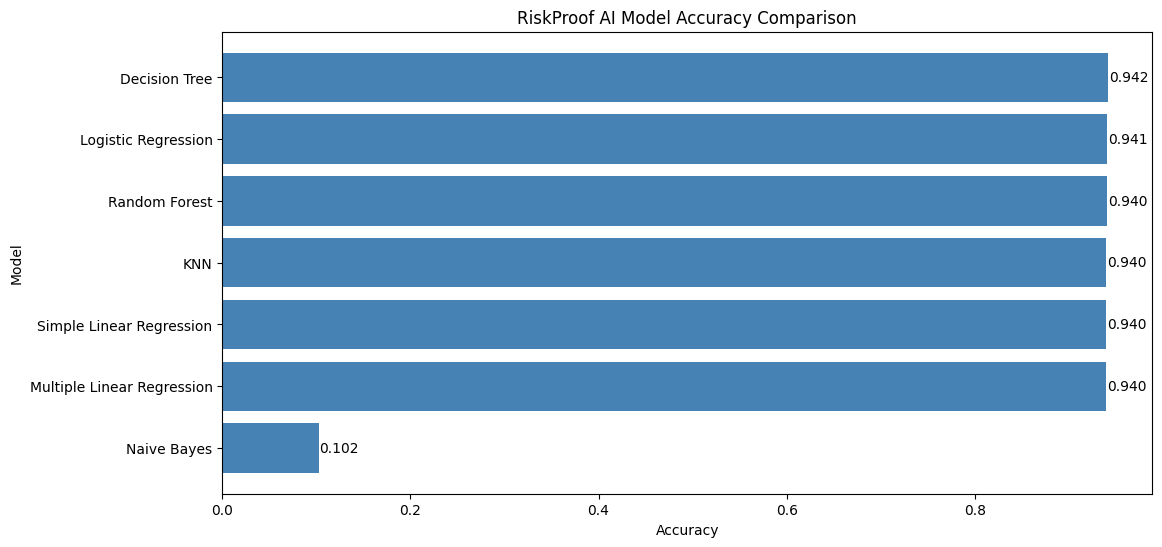

In [34]:
plt.figure(figsize=(12, 6))
plot_df = comparison_df.sort_values('accuracy', ascending=True)
plt.barh(plot_df['model'], plot_df['accuracy'], color='steelblue')
plt.xlabel('Accuracy')
plt.ylabel('Model')
plt.title('RiskProof AI Model Accuracy Comparison')
for index, value in enumerate(plot_df['accuracy']):
    plt.text(value + 0.001, index, f'{value:.3f}', va='center')
plt.show()

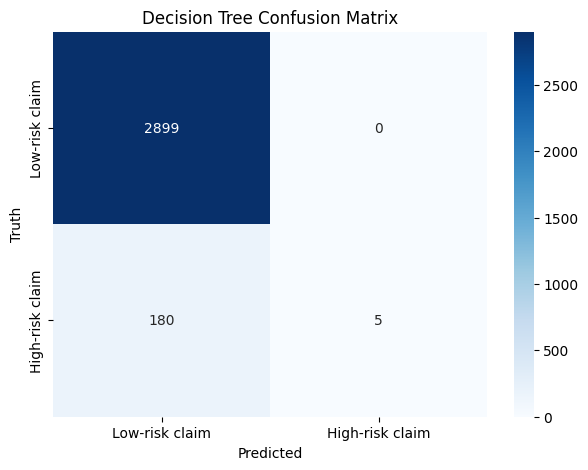

In [35]:
best_cm = None
best_cm_labels = None

if best_binary_model_name == 'Logistic Regression':
    best_cm = cm_lr
    best_cm_labels = ['Low-risk claim', 'High-risk claim']
elif best_binary_model_name == 'Decision Tree':
    best_cm = confusion_matrix(y_test, best_tree.predict(X_test))
    best_cm_labels = ['Low-risk claim', 'High-risk claim']
elif best_binary_model_name == 'Random Forest':
    best_cm = confusion_matrix(y_test, best_rf.predict(X_test))
    best_cm_labels = ['Low-risk claim', 'High-risk claim']
elif best_binary_model_name == 'SVM':
    best_cm = confusion_matrix(y_test, svm_pred)
    best_cm_labels = ['Low-risk claim', 'High-risk claim']
elif best_binary_model_name == 'Naive Bayes':
    best_cm = confusion_matrix(y_test, best_nb.predict(X_test_nb))
    best_cm_labels = ['Low-risk claim', 'High-risk claim']
elif best_binary_model_name == 'KNN':
    best_cm = confusion_matrix(y_test, best_knn.predict(X_test))
    best_cm_labels = ['Low-risk claim', 'High-risk claim']
elif best_binary_model_name == 'KMeans':
    best_cm = confusion_matrix(y_test, best_km_predictions)
    best_cm_labels = ['Low-risk claim', 'High-risk claim']
else:
    best_cm = confusion_matrix(y_test, best_lr.predict(X_test_lr))
    best_cm_labels = ['Low-risk claim', 'High-risk claim']

plt.figure(figsize=(7, 5))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_cm_labels, yticklabels=best_cm_labels)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title(f'{best_binary_model_name} Confusion Matrix')
plt.show()

## Individual Confusion Matrix Visuals

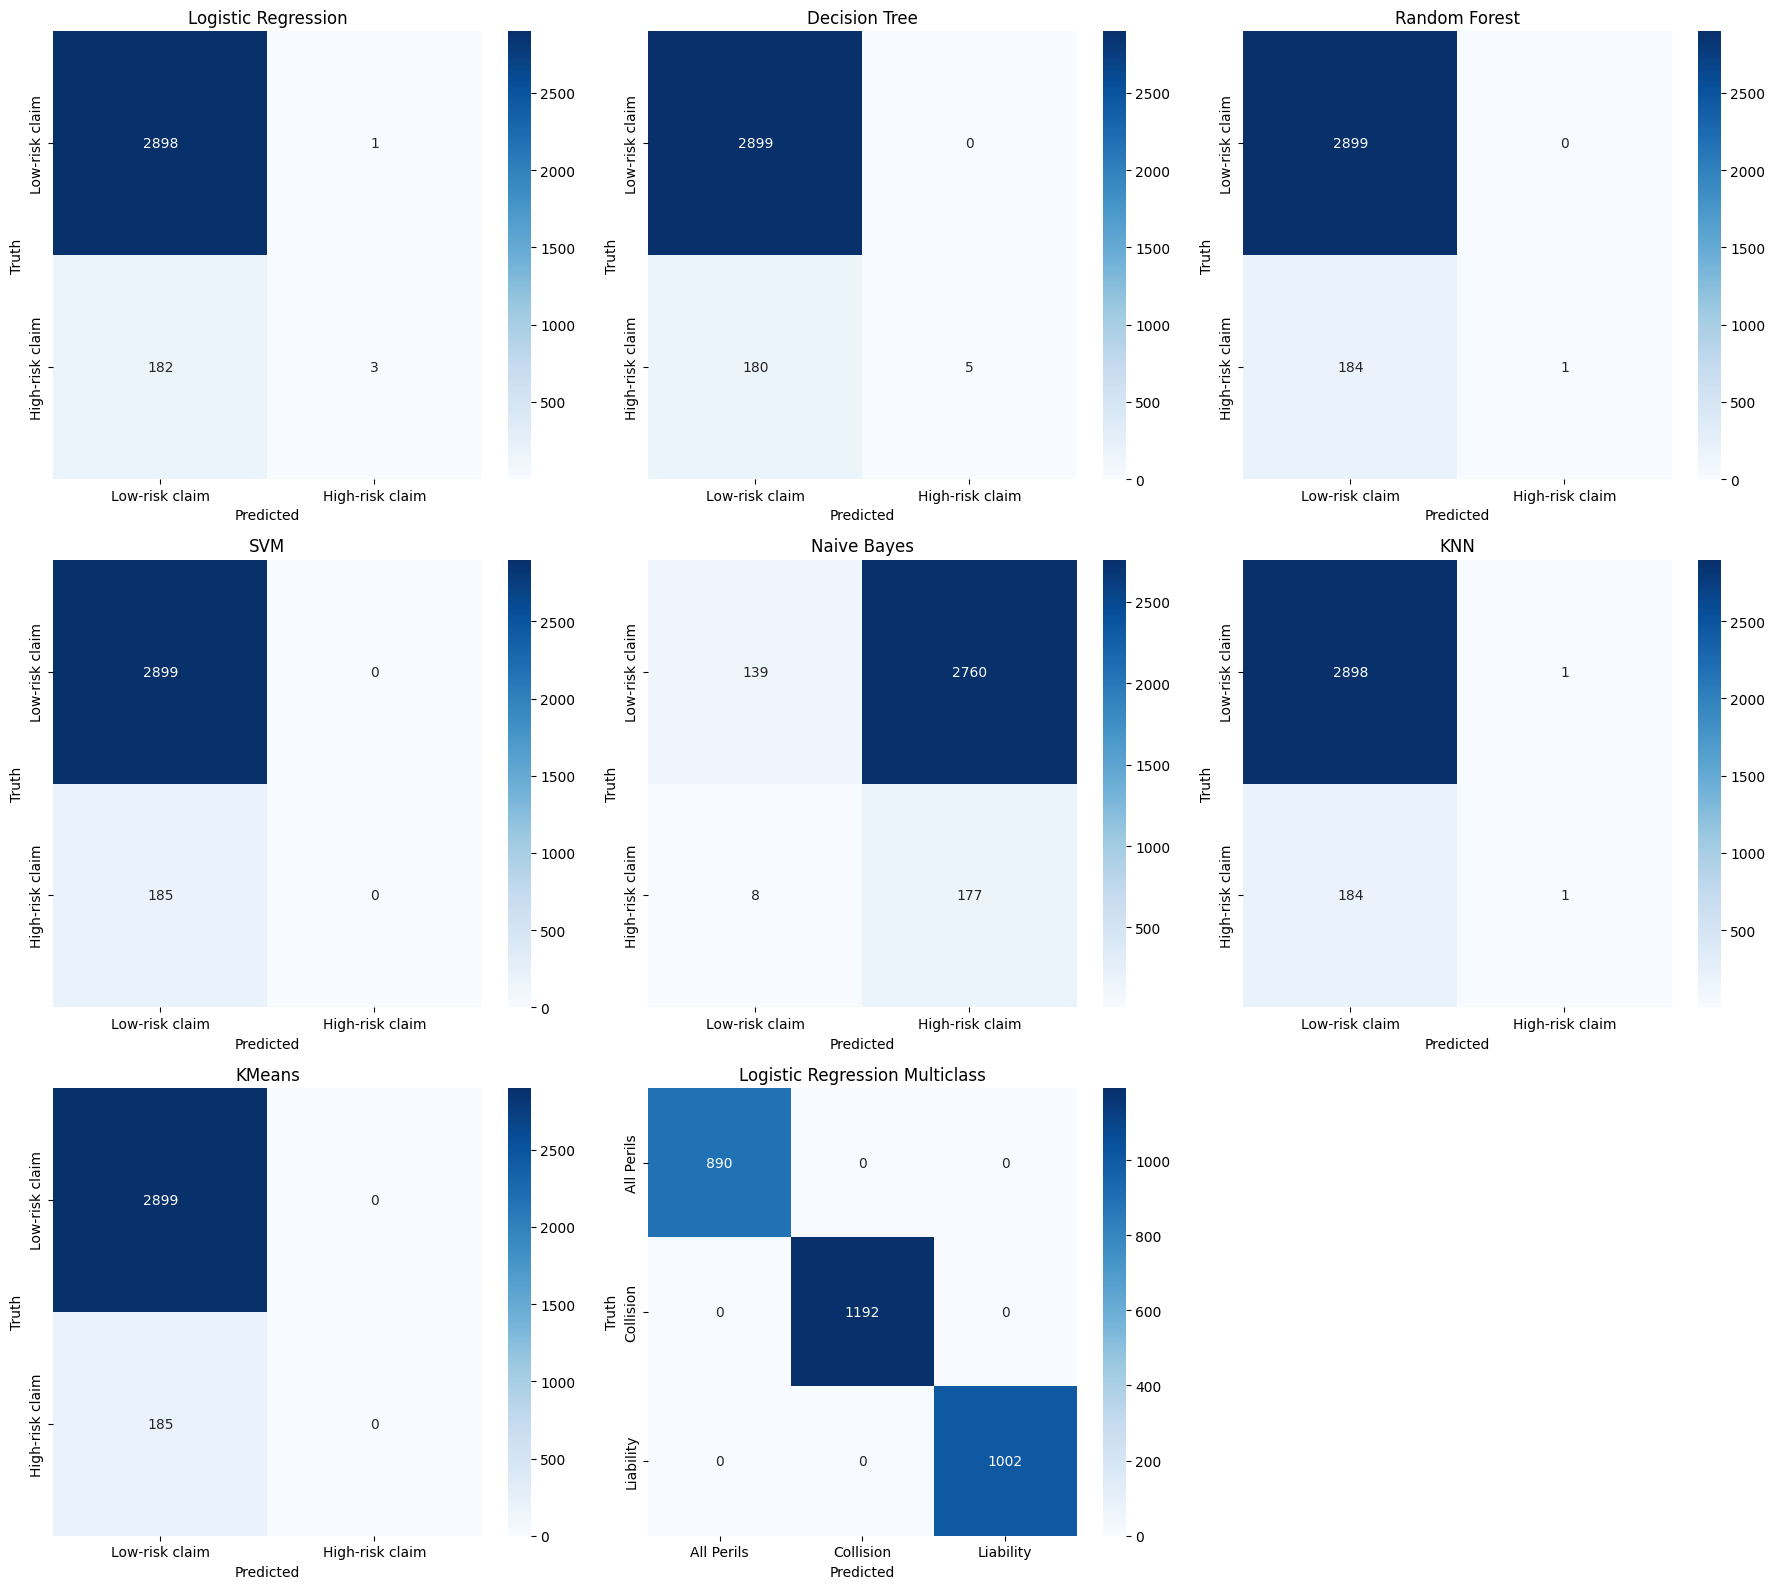

In [36]:
def plot_cm(ax, cm, title, labels):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Truth')

binary_labels = ['Low-risk claim', 'High-risk claim']
multiclass_labels = multiclass_encoder.classes_.tolist()

fig, axes = plt.subplots(3, 3, figsize=(18, 16))
axes = axes.flatten()

plot_cm(axes[0], confusion_matrix(y_test, y_pred_lr), 'Logistic Regression', binary_labels)
plot_cm(axes[1], confusion_matrix(y_test, best_tree.predict(X_test)), 'Decision Tree', binary_labels)
plot_cm(axes[2], confusion_matrix(y_test, best_rf.predict(X_test)), 'Random Forest', binary_labels)
plot_cm(axes[3], confusion_matrix(y_test, svm_pred), 'SVM', binary_labels)
plot_cm(axes[4], confusion_matrix(y_test, best_nb.predict(X_test_nb)), 'Naive Bayes', binary_labels)
plot_cm(axes[5], confusion_matrix(y_test, best_knn.predict(X_test)), 'KNN', binary_labels)
plot_cm(axes[6], confusion_matrix(y_test, best_km_predictions), 'KMeans', binary_labels)
plot_cm(axes[7], confusion_matrix(y_test_mc, mc_pred), 'Logistic Regression Multiclass', multiclass_labels)
axes[8].axis('off')
plt.tight_layout()
plt.show()

## 15. Save Best Model

In [37]:
best_binary_model_info = trained_models[best_binary_model_name]
best_model_object = best_binary_model_info['model']
best_scaler_object = best_binary_model_info.get('scaler')

best_model_bundle = {
    'model_name': best_binary_model_name,
    'model': best_model_object,
    'scaler': best_scaler_object,
    'cluster_mapping': best_binary_model_info.get('cluster_mapping'),
    'feature_columns': inputs.columns.tolist(),
    'best_accuracy': float(best_binary_accuracy),
    'risk_label_map': {0: 'Low-risk claim', 1: 'High-risk claim'},
    'multiclass_target_classes': multiclass_encoder.classes_.tolist()
}

with open('riskproof_ai_best_model.pkl', 'wb') as f:
    pickle.dump(best_model_bundle, f)

joblib.dump(best_model_bundle, 'riskproof_ai_best_model.joblib')
print('Saved model files: riskproof_ai_best_model.pkl and riskproof_ai_best_model.joblib')

Saved model files: riskproof_ai_best_model.pkl and riskproof_ai_best_model.joblib
